In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sn
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [ ]:
# Load the 'unsupervised-learning-on-country-data' dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path_country_data = "Country-data.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rohan0301/unsupervised-learning-on-country-data",
  file_path_country_data,
)

print("First 5 records of country_df:")
display(df.head())

/tmp/ipykernel_1867/1215707381.py:6: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
First 5 records of country_df:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Project Flow (Ideal Data Science Lifecycle)
### 1. Import Libraries
### 2. Load Dataset
### 3. Understand the Dataset
``` Shape
1. Columns
2. Data Types
3. Missing Values
4. Duplicate Values
5. Statistical Summary
```
### 4. Data Cleaning
``` This dataset is already very clean.

We'll only check

1. Missing Values
2. Duplicate Values
3. Wrong Data Types

No feature engineering is required because this is an unsupervised learning dataset.
```
### 5. Basic EDA
```
Numerical Distribution
Correlation Heatmap
Top 10 lowest Income Countries
GDP Distribution
Life Expectancy  Distribution
```
### 6. Feature Selection
```
Country name cannot be used.
Explain:
Country is just an identifier.
Machine learns only from numerical values.
```

### 7. Feature Scaling
```
K-Means is distance based.
So scaling is compulsory.
```
### 8. Create Dendrogram
### 9. Create Model
### 10. Show Result
### 11. Interpretation

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<Axes: >

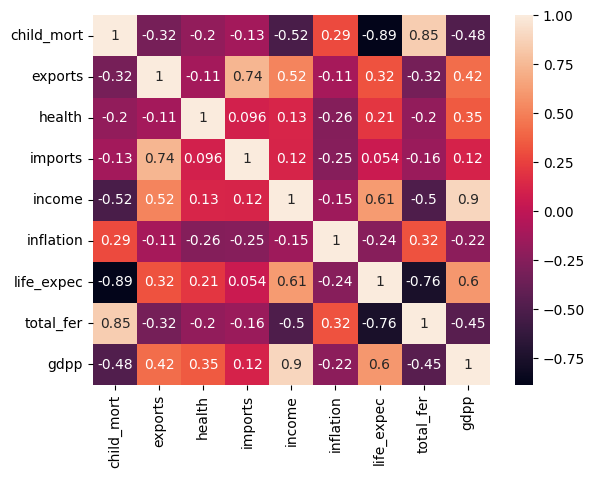

In [ ]:
# Corr
corr = df.corr(numeric_only= True)
sn.heatmap(corr , annot = True )

In [ ]:
country_income = df.sort_values( by ='income' , ascending = True)
country_income.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.80,57.5,6.54,334
88,Liberia,89.3,19.10,11.80,92.6,700,5.47,60.8,5.02,327
26,Burundi,93.6,8.92,11.60,39.2,764,12.30,57.7,6.26,231
112,Niger,123.0,22.20,5.16,49.1,814,2.55,58.8,7.49,348
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.01,47.5,5.21,446
106,Mozambique,101.0,31.50,5.21,46.2,918,7.64,54.5,5.56,419
94,Malawi,90.5,22.80,6.59,34.9,1030,12.10,53.1,5.31,459
63,Guinea,109.0,30.30,4.93,43.2,1190,16.10,58.0,5.34,648
150,Togo,90.3,40.20,7.65,57.3,1210,1.18,58.7,4.87,488
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.20,55.0,5.20,399


In [ ]:
df.drop('country', axis = 1 )

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Drop the 'country' column as it contains non-numeric data
df_scaled = df.drop('country', axis=1)

X_scaler = scaler.fit_transform(df_scaled)
X_scaler

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

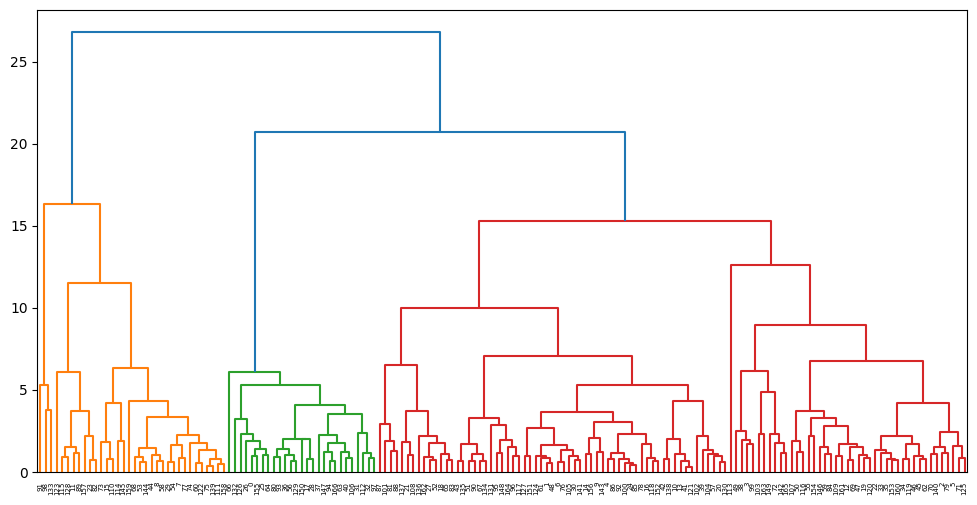

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
plt.figure(figsize = (12, 6))

link = linkage(X_scaler , method = 'ward')
dendrogram(link)
plt.show()

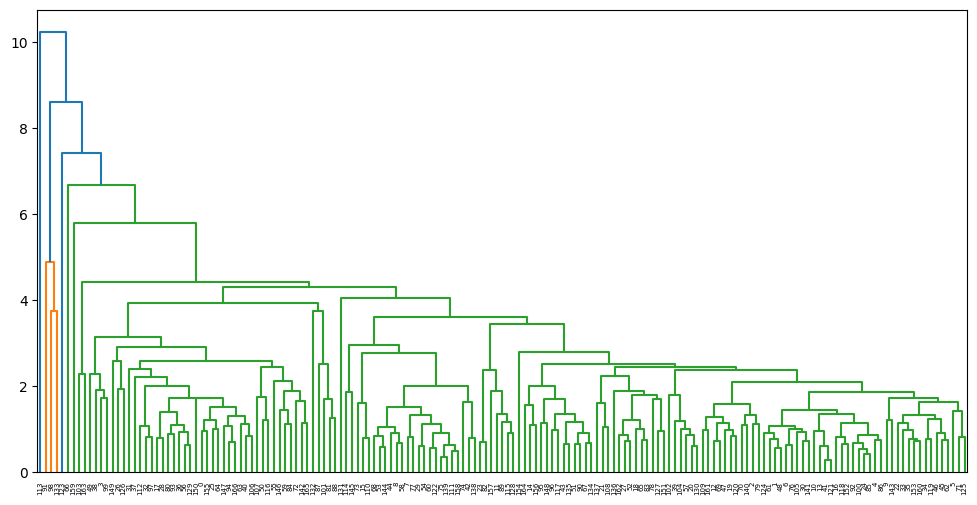

In [ ]:
plt.figure(figsize = (12, 6))

link = linkage(X_scaler , method = 'average')
dendrogram(link)
plt.show()

In [ ]:
# MOdeling
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters = 3)
df['cluster'] = model.fit_predict(X_scaler)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


In [ ]:

fig = px.scatter(df, x='income', y='gdpp', color='cluster',
                 hover_data=['country', 'child_mort', 'exports', 'imports', 'health', 'life_expec', 'total_fer', 'inflation'],
                 title='Country Clusters based on Income and GDP per capita')
fig.show()

In [ ]:
fig_3d = px.scatter_3d(df, x='income', y='gdpp', z='life_expec', color='cluster',
                       hover_data=['country', 'child_mort', 'exports', 'imports', 'health', 'total_fer', 'inflation'],
                       title='Country Clusters in 3D (Income, GDP per capita, Life Expectancy)')
fig_3d.update_layout(template='plotly_dark')
fig_3d.show()

In [ ]:
from numpy._core import numeric
df.groupby('cluster').mean(numeric_only = True)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889


In [ ]:
cluster_means = df.groupby('cluster').mean(numeric_only=True).reset_index()
display(cluster_means)

,cluster,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235
1,1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925
2,2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889


### Cluster Characteristics Visualization

In [ ]:
fig_cluster_means = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Average Child Mortality by Cluster', 'Average Income by Cluster', 'Average GDP per Capita by Cluster')
)

fig_cluster_means.add_trace(
    go.Bar(x=cluster_means['cluster'], y=cluster_means['child_mort'], name='Child Mortality'),
    row=1, col=1
)

fig_cluster_means.add_trace(
    go.Bar(x=cluster_means['cluster'], y=cluster_means['income'], name='Income'),
    row=1, col=2
)

fig_cluster_means.add_trace(
    go.Bar(x=cluster_means['cluster'], y=cluster_means['gdpp'], name='GDP per Capita'),
    row=1, col=3
)

fig_cluster_means.update_layout(height=400, showlegend=False, title_text="Key Feature Averages by Cluster", template='plotly_dark')
fig_cluster_means.show()